## Week 5 — Handling Imbalanced & Messy Real-World Data

## Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [44]:
df = pd.read_csv(r"D:\neurofive_ml_track\Week_05\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
print("\nColumn Names:")
df.columns


Column Names:


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [46]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [47]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [48]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges:
[ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]

TotalC

## Data Cleaning

In [49]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values in TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

Missing values in TotalCharges after conversion:
11


In [50]:
# Fill missing TotalCharges values using the median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [51]:
print("Churn Value Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Class Imbalance

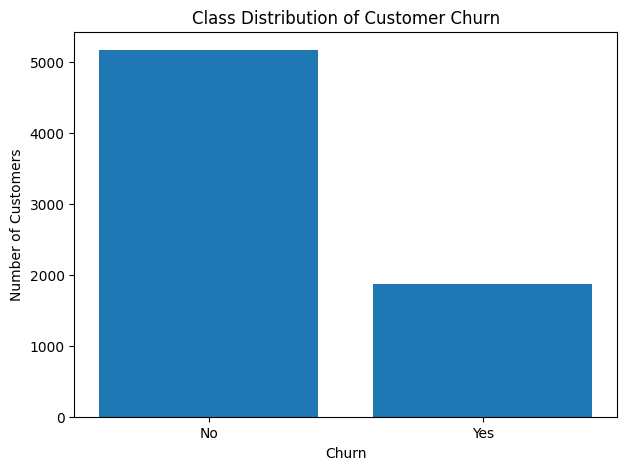

In [52]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Class Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [53]:
class_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Class Distribution:")
print(class_percentage)

Class Distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [54]:
df = df.drop("customerID", axis=1)

print("Shape after dropping customerID:")
print(df.shape)

Shape after dropping customerID:
(7043, 20)


In [55]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [56]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [57]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded feature shape:", X.shape)

X.head()

Encoded feature shape: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [58]:
X = X.astype(int)

print(X.dtypes.value_counts())

int64    30
Name: count, dtype: int64


## Train/Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (5634, 30)
Testing set: (1409, 30)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


## Feature Scaling

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Baseline Model

In [61]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [62]:
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [63]:
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline
)

print("Baseline Model Performance")
print("-" * 35)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")

Baseline Model Performance
-----------------------------------
Accuracy:  0.8070
Precision: 0.6584
Recall:    0.5668
F1 Score:  0.6092


In [64]:
print("Baseline Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["No Churn", "Churn"]
    )
)

Baseline Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Baseline Confusion Matrix:
[[925 110]
 [162 212]]


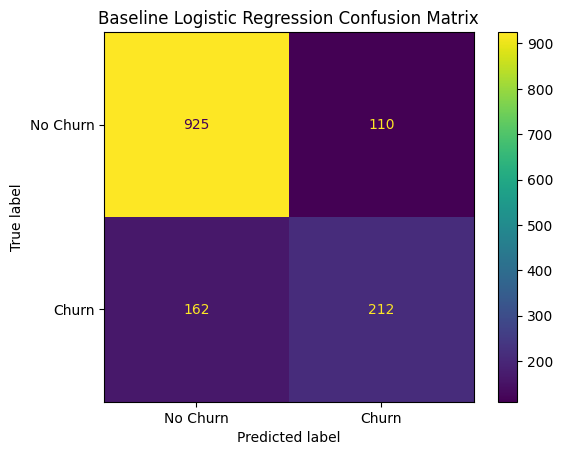

In [65]:
cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

print("Baseline Confusion Matrix:")
print(cm_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

## Apply SMOTE

In [66]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [67]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE applied successfully!")

print("\nOriginal training set:")
print(y_train.value_counts())

print("\nBalanced training set:")
print(y_train_smote.value_counts())

SMOTE applied successfully!

Original training set:
Churn
0    4139
1    1495
Name: count, dtype: int64

Balanced training set:
Churn
0    4139
1    4139
Name: count, dtype: int64


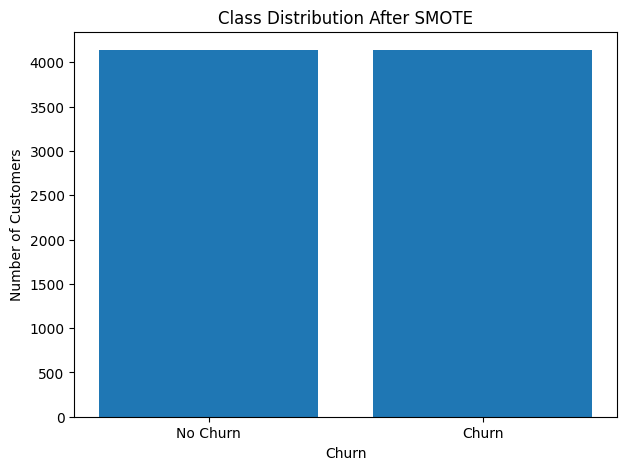

In [68]:
smote_counts = y_train_smote.value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Churn", "Churn"],
    [
        smote_counts[0],
        smote_counts[1]
    ]
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Train Balanced Model

In [69]:
smote_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression trained successfully.")

SMOTE Logistic Regression trained successfully.


In [70]:
y_pred_smote = smote_model.predict(
    X_test_scaled
)

print("SMOTE predictions generated.")

SMOTE predictions generated.


In [71]:
smote_accuracy = accuracy_score(
    y_test,
    y_pred_smote
)

smote_precision = precision_score(
    y_test,
    y_pred_smote
)

smote_recall = recall_score(
    y_test,
    y_pred_smote
)

smote_f1 = f1_score(
    y_test,
    y_pred_smote
)

print("SMOTE Model Performance")
print("-" * 35)

print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1 Score:  {smote_f1:.4f}")

SMOTE Model Performance
-----------------------------------
Accuracy:  0.7395
Precision: 0.5059
Recall:    0.7995
F1 Score:  0.6197


In [72]:
print("SMOTE Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=["No Churn", "Churn"]
    )
)

SMOTE Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



SMOTE Confusion Matrix:
[[743 292]
 [ 75 299]]


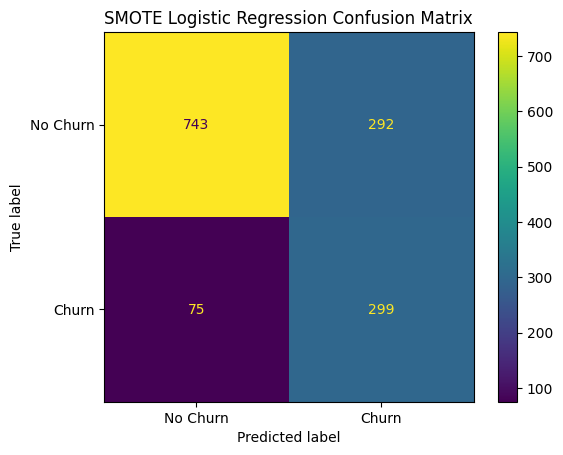

In [73]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("SMOTE Confusion Matrix:")
print(cm_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("SMOTE Logistic Regression Confusion Matrix")
plt.show()

## Compare Models

In [74]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Before SMOTE": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "After SMOTE": [
        smote_accuracy,
        smote_precision,
        smote_recall,
        smote_f1
    ]
})

comparison

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.806955,0.739532
1,Precision,0.658385,0.505922
2,Recall,0.566845,0.799465
3,F1 Score,0.609195,0.619689


In [75]:
comparison_display = comparison.copy()

comparison_display[
    ["Before SMOTE", "After SMOTE"]
] = comparison_display[
    ["Before SMOTE", "After SMOTE"]
].applymap(
    lambda x: f"{x * 100:.2f}%"
)

comparison_display

,Metric,Before SMOTE,After SMOTE
0,Accuracy,80.70%,73.95%
1,Precision,65.84%,50.59%
2,Recall,56.68%,79.95%
3,F1 Score,60.92%,61.97%


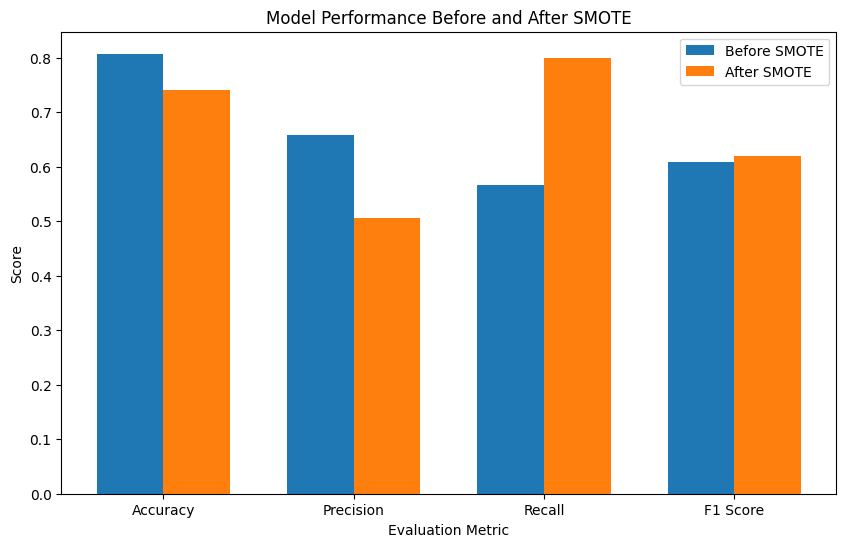

In [76]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

before_values = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
]

after_values = [
    smote_accuracy,
    smote_precision,
    smote_recall,
    smote_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    before_values,
    width,
    label="Before SMOTE"
)

plt.bar(
    x + width / 2,
    after_values,
    width,
    label="After SMOTE"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Model Performance Before and After SMOTE")

plt.legend()

plt.show()

In [77]:
improvements = {
    "Precision Improvement": smote_precision - baseline_precision,
    "Recall Improvement": smote_recall - baseline_recall,
    "F1 Improvement": smote_f1 - baseline_f1,
    "Accuracy Change": smote_accuracy - baseline_accuracy
}

for metric, value in improvements.items():
    print(f"{metric}: {value:+.4f}")

Precision Improvement: -0.1525
Recall Improvement: +0.2326
F1 Improvement: +0.0105
Accuracy Change: -0.0674


## Why Accuracy Is Misleading
Why Accuracy Can Be Misleading:

Accuracy measures the percentage of all predictions that are correct.

In an imbalanced dataset, the majority class can dominate the accuracy
score. For example, if 73% of customers do not churn, a model that predicts
"No Churn" for almost every customer could achieve around 73% accuracy
without being useful for identifying customers who will actually churn.

The minority class is often the class that we care about most.

In this dataset, identifying customers who are likely to churn is important.
Therefore, Precision, Recall and F1-score provide a better understanding
of model performance.

Recall is particularly important because it tells us how many actual
churning customers the model successfully identifies.

F1-score combines Precision and Recall into a single metric and is useful
when we want a balance between the two.

Therefore, for this task we should not rely on accuracy alone.

## Precision, Recall and F1 Explanation
Evaluation Metrics:

1. Precision:
   Of the customers predicted to churn, how many actually churned?

2. Recall:
   Of the customers who actually churned, how many did the model identify?

3. F1 Score:
   The harmonic mean of Precision and Recall.

4. Accuracy:
   The percentage of all predictions that are correct.

For an imbalanced classification problem, Precision, Recall and F1-score
are generally more informative than accuracy alone.

## Final Results

In [78]:
print("=" * 55)
print("FINAL MODEL COMPARISON")
print("=" * 55)

print("\nBefore SMOTE:")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")

print("\nAfter SMOTE:")
print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1 Score:  {smote_f1:.4f}")

FINAL MODEL COMPARISON

Before SMOTE:
Accuracy:  0.8070
Precision: 0.6584
Recall:    0.5668
F1 Score:  0.6092

After SMOTE:
Accuracy:  0.7395
Precision: 0.5059
Recall:    0.7995
F1 Score:  0.6197


In [79]:
if smote_f1 > baseline_f1:
    print("SMOTE model achieved a higher F1-score.")
    print("SMOTE improved the balance between Precision and Recall.")
else:
    print("The baseline model achieved a higher F1-score.")
    print("SMOTE did not improve the F1-score in this experiment.")

SMOTE model achieved a higher F1-score.
SMOTE improved the balance between Precision and Recall.


## Save Results

In [80]:
comparison.to_csv(
    "week5_model_comparison.csv",
    index=False
)

print("Model comparison saved as week5_model_comparison.csv")

Model comparison saved as week5_model_comparison.csv


## Conclusion:

The baseline Logistic Regression model achieved an accuracy of 80.70%,
but its recall for the churn class was only 56.68%. After applying SMOTE,
accuracy decreased to 73.95%, but recall increased significantly to 79.95%.

The F1-score also improved slightly from 60.92% to 61.97%.

This demonstrates why accuracy alone can be misleading when working with
imbalanced datasets. Although the SMOTE model has lower accuracy, it is
much better at identifying customers who are actually likely to churn.

The decrease in precision from 65.84% to 50.59% shows that the model also
produced more false positive churn predictions. However, in a churn
prediction problem, identifying more actual churn customers can be more
valuable than simply maximizing overall accuracy.

Therefore, Precision, Recall, and F1-score provide a more meaningful
evaluation of the model than accuracy alone.